# LSTM financial sentiment

Base model: `arjahojnik/LSTM-sentiment-model`

This notebook uses the pretrained LSTM checkpoint and its shipped tokenizer, replaces the original sentiment head with a 3-class head, then trains in two stages: head-only first, then partial end-to-end fine-tuning.

In [7]:
from pathlib import Path
import sys

import pandas as pd
from tensorflow import keras
from IPython.display import display

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from utils.text_utils import (
    download_hf_file,
    evaluate_keras_model,
    keras_text_splits,
    load_data,
    load_pickle_tokenizer,
    metrics_table,
    plot_history,
    replace_keras_classifier,
    set_seed,
    summarize_splits,
    train_keras_transfer_model,
)

set_seed(42)

In [8]:
BASE_REPO = "arjahojnik/LSTM-sentiment-model"
BASE_MODEL_FILE = "LSTM_model.h5"

df = load_data()
display(summarize_splits(df))
df.head()

,rows,mean_words,negative,neutral,positive
split,,,,,
test,23566,17.30,5817,7306,10443
train,77589,18.01,18856,25403,33330
validation,23567,17.36,5722,7261,10584


,dataset_id,dataset_label,source_platform,split,text,label_normalized,label_id
0,lwrf42/financial-sentiment-dataset,lwrf42_financial_sentiment_dataset,huggingface,train,general announcement monthly valuation of asse...,neutral,1
1,lwrf42/financial-sentiment-dataset,lwrf42_financial_sentiment_dataset,huggingface,train,cowen survey forecasts stores to reopen in jun...,positive,2
2,lwrf42/financial-sentiment-dataset,lwrf42_financial_sentiment_dataset,huggingface,train,aap weak no volume,negative,0
3,lwrf42/financial-sentiment-dataset,lwrf42_financial_sentiment_dataset,huggingface,train,rt robbielolz nflx a close above here is looki...,positive,2
4,lwrf42/financial-sentiment-dataset,lwrf42_financial_sentiment_dataset,huggingface,train,apple s aapl third quarter fiscal earnings ben...,positive,2


In [9]:
tokenizer = load_pickle_tokenizer(BASE_REPO)
base_model_path = download_hf_file(BASE_REPO, BASE_MODEL_FILE)
base_model = keras.models.load_model(base_model_path, compile=False)
base_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (32, 200, 100)         │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (32, 64)               │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (32, 64)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 128)              │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 5)                │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,051,205 (4.01 MB)

 Trainable params: 51,205 (200.02 KB)

 Non-trainable params: 1,000,000 (3.81 MB)

In [10]:
max_length = int(base_model.input_shape[1])
splits = keras_text_splits(df, tokenizer=tokenizer, max_length=max_length)

x_train, y_train = splits["train"]
x_valid, y_valid = splits["validation"]
x_test, y_test = splits["test"]

transfer_model = replace_keras_classifier(base_model, num_classes=3)
transfer_model.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ transfer_input (InputLayer)     │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 200, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transfer_head (Dense)           │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,050,947 (4.01 MB)

 Trainable params: 50,947 (199.01 KB)

 Non-trainable params: 1,000,000 (3.81 MB)

Epoch 1/4
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 31s 25ms/step - accuracy: 0.4279 - loss: 1.0743 - val_accuracy: 0.4491 - val_loss: 1.0681
Epoch 2/4
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 33s 27ms/step - accuracy: 0.4296 - loss: 1.0726 - val_accuracy: 0.4491 - val_loss: 1.0677
Epoch 3/4
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 33s 28ms/step - accuracy: 0.4296 - loss: 1.0726 - val_accuracy: 0.4491 - val_loss: 1.0677
Epoch 4/4
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 30s 25ms/step - accuracy: 0.4296 - loss: 1.0725 - val_accuracy: 0.4491 - val_loss: 1.0670
Epoch 1/6
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 37s 30ms/step - accuracy: 0.4296 - loss: 1.0724 - val_accuracy: 0.4491 - val_loss: 1.0632
Epoch 2/6
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 37s 30ms/step - accuracy: 0.4296 - loss: 1.0535 - val_accuracy: 0.4491 - val_loss: 1.0237
Epoch 3/6
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 37s 30ms/step - accuracy: 0.4522 - loss: 1.0136 - val_accuracy: 0.5065 - val_loss: 0.9960
Epoch 4/6
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 37s 30ms/step - accuracy: 0.5029 - loss: 0

,epoch,train_loss,validation_loss,validation_accuracy
0,1,1.074275,1.068086,0.449103
1,2,1.072635,1.067691,0.449103
2,3,1.072581,1.067701,0.449103
3,4,1.072528,1.067048,0.449103
4,5,1.072391,1.063244,0.449103
5,6,1.053540,1.023731,0.449060
6,7,1.013572,0.996041,0.506513
7,8,0.989553,0.978650,0.521365
8,9,0.970856,0.959090,0.532736
9,10,0.955270,0.940558,0.552807


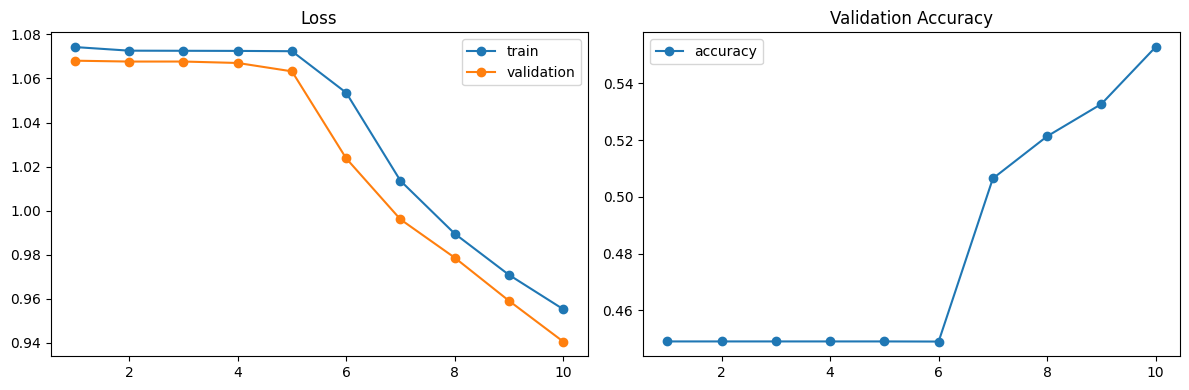

In [11]:
history = train_keras_transfer_model(
    transfer_model,
    train_data=(x_train, y_train),
    validation_data=(x_valid, y_valid),
    head_epochs=4,
    full_epochs=6,
    head_learning_rate=1e-3,
    full_learning_rate=1e-4,
    batch_size=64,
    unfreeze_layers_from_end=4,
)

plot_history(history)
history

In [12]:
test_texts = df[df["split"] == "test"]["text"].tolist()
results = evaluate_keras_model(transfer_model, x_test, y_test, texts=test_texts)
display(metrics_table(results))
display(results["report"])
display(results["confusion_matrix"])
results["predictions"].head()

,metric,value
0,accuracy,0.551600
1,macro_precision,0.524732
2,macro_recall,0.532065
3,macro_f1,0.503045
4,weighted_f1,0.517064


,precision,recall,f1-score,support
negative,0.536162,0.669073,0.595289,5817.0000
neutral,0.457465,0.183274,0.261702,7306.0000
positive,0.580568,0.743848,0.652143,10443.0000
accuracy,0.551600,0.551600,0.551600,0.5516
macro avg,0.524732,0.532065,0.503045,23566.0000
weighted avg,0.531442,0.551600,0.517064,23566.0000


,negative,neutral,positive
negative,3892,605,1320
neutral,1675,1339,4292
positive,1692,983,7768


,text,label,prediction
0,hqge ltnc hbrm enzc eeenf halb azfl maxd mmex ...,positive,positive
1,econx november nonfarm private payrolls k vs k...,positive,negative
2,regulatory news the nomination committee of cy...,neutral,neutral
3,amazon labor union is now seeking to represent...,positive,negative
4,greene king s third quarter sales boosted by f...,positive,positive
